# Qualitative Comparison: YOLO OBB (x-only vs XT+SC)

This notebook generates 2x4 qualitative comparison figures.
Layout:
- [0,0]: original grayscale + GT
- [0,1..3], [1,0..2]: baselines (v8n, v11n, v26n, v11s, v11m, v11x)
- [1,3]: our method (v11n + XT+SC)

Edit `SAMPLE_IDS` or use `select_hard_samples()` to pick challenging samples.

In [35]:
import os
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt

from ultralytics import YOLO


In [36]:
# --------- Paths ---------
ROOT = Path('/home/chris/ultralytics')
DATA = ROOT / 'dataset/obb_xt_clean'
IMG_X_VAL = DATA / 'images/val'
IMG_XT_VAL = DATA / 'images/val_xt'
# Display base image (projection-only, no extra suppression)
DISPLAY_BASE = Path(ROOT / 'dataset/obb_xt/images/train')
if not DISPLAY_BASE.exists():
    DISPLAY_BASE = IMG_XT_VAL




IMG_XTSC_VAL = DATA / 'images/val_xt_sc'
LBL_X_VAL = DATA / 'labels/val'
LBL_XTSC_VAL = DATA / 'labels/val_xt_sc'

# Baseline (x-only) best weights
WEIGHTS_X = {
    'v8n': ROOT / 'runs/obb/cmp_v8n_x_cmp100_xonly_v8v11v26_v11scalex_20260402/weights/best.pt',
    'v11n': ROOT / 'runs/obb/cmp_v11n_x_cmp100_xonly_v8v11v26_v11scalex_20260402/weights/best.pt',
    'v26n': ROOT / 'runs/obb/cmp_v26n_x_cmp100_xonly_v8v11v26_v11scalex_20260402/weights/best.pt',
    'v11s': ROOT / 'runs/obb/cmp_v11s_x_cmp100_xonly_v8v11v26_v11scalex_20260402/weights/best.pt',
    'v11m': ROOT / 'runs/obb/cmp_v11m_x_cmp100_xonly_v8v11v26_v11scalex_20260402/weights/best.pt',
    'v11x': ROOT / 'runs/obb/cmp_v11x_x_cmp100_xonly_v8v11v26_v11scalex_20260402/weights/best.pt',
}

# Our method (XT+SC)
WEIGHTS_OURS = ROOT / 'runs/obb/cmp_xt_sc_endpoint_v1_gpu_full/weights/best.pt'

# Inference settings
IMG_SIZE = 1024
CONF = 0.25
IOU = 0.7
DEVICE = 0


In [37]:
def load_image_gray(path: Path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(path)
    return img

def read_obb_label(path: Path, w: int, h: int):
    polys = []
    if not path.exists():
        return polys
    with open(path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) != 9:
                continue
            coords = list(map(float, parts[1:]))
            pts = np.array(coords, dtype=np.float32).reshape(-1, 2)
            # normalized coords -> pixel coords
            pts[:, 0] *= w
            pts[:, 1] *= h
            polys.append(pts.astype(np.int32))
    return polys

def draw_polys(img_gray, polys, color=(0, 255, 0), thickness=2):
    img = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR) if img_gray.ndim == 2 else img_gray.copy()
    for pts in polys:
        cv2.polylines(img, [pts], isClosed=True, color=color, thickness=thickness)
    return img

def predict_polys(model, img_path: Path):
    results = model.predict(source=str(img_path), imgsz=IMG_SIZE, conf=CONF, iou=IOU, device=DEVICE, verbose=False)
    if not results:
        return []
    r = results[0]
    if getattr(r, 'obb', None) is None:
        return []
    obb = r.obb
    if hasattr(obb, 'xyxyxyxy') and obb.xyxyxyxy is not None:
        polys = obb.xyxyxyxy.cpu().numpy().astype(np.int32)
        return [p.reshape(-1, 2) for p in polys]
    # Fallback: use xywhr to construct polygons
    if hasattr(obb, 'xywhr') and obb.xywhr is not None:
        polys = []
        xywhr = obb.xywhr.cpu().numpy()
        for x, y, w, h, r in xywhr:
            rect = ((float(x), float(y)), (float(w), float(h)), float(r * 180.0 / np.pi))
            box = cv2.boxPoints(rect).astype(np.int32)
            polys.append(box)
        return polys
    return []


In [38]:
def select_hard_samples(n=3):
    # Heuristic: low contrast + more targets
    scores = []
    for p in sorted(IMG_X_VAL.glob('*.png')):
        img = load_image_gray(p)
        contrast = img.std()
        lbl = LBL_X_VAL / (p.stem + '.txt')
        num = 0
        if lbl.exists():
            with open(lbl, 'r') as f:
                num = sum(1 for _ in f if _.strip())
        # lower contrast + more targets -> higher score
        score = (1.0 / (contrast + 1e-6)) + 0.05 * num
        scores.append((score, p.name))
    scores.sort(reverse=True)
    return [name for _, name in scores[-n:]]

# Option 1: manual list
SAMPLE_IDS = [
    '341.png',
    '493.png',
    '189.png',
    '598.png',
]

# Option 2: auto-select hard samples
# SAMPLE_IDS = select_hard_samples(n=10)
print('Samples:', SAMPLE_IDS)


Samples: ['341.png', '493.png', '189.png', '598.png']


In [39]:
# Display image loader (projection-only, no extra suppression)
def load_display_image(sample_name: str):
    xt =  cv2.imread(DISPLAY_BASE / sample_name, -1)
    return xt[..., 0]


Saved: /home/chris/ultralytics/runs/obb/qualitative/qual_341.png


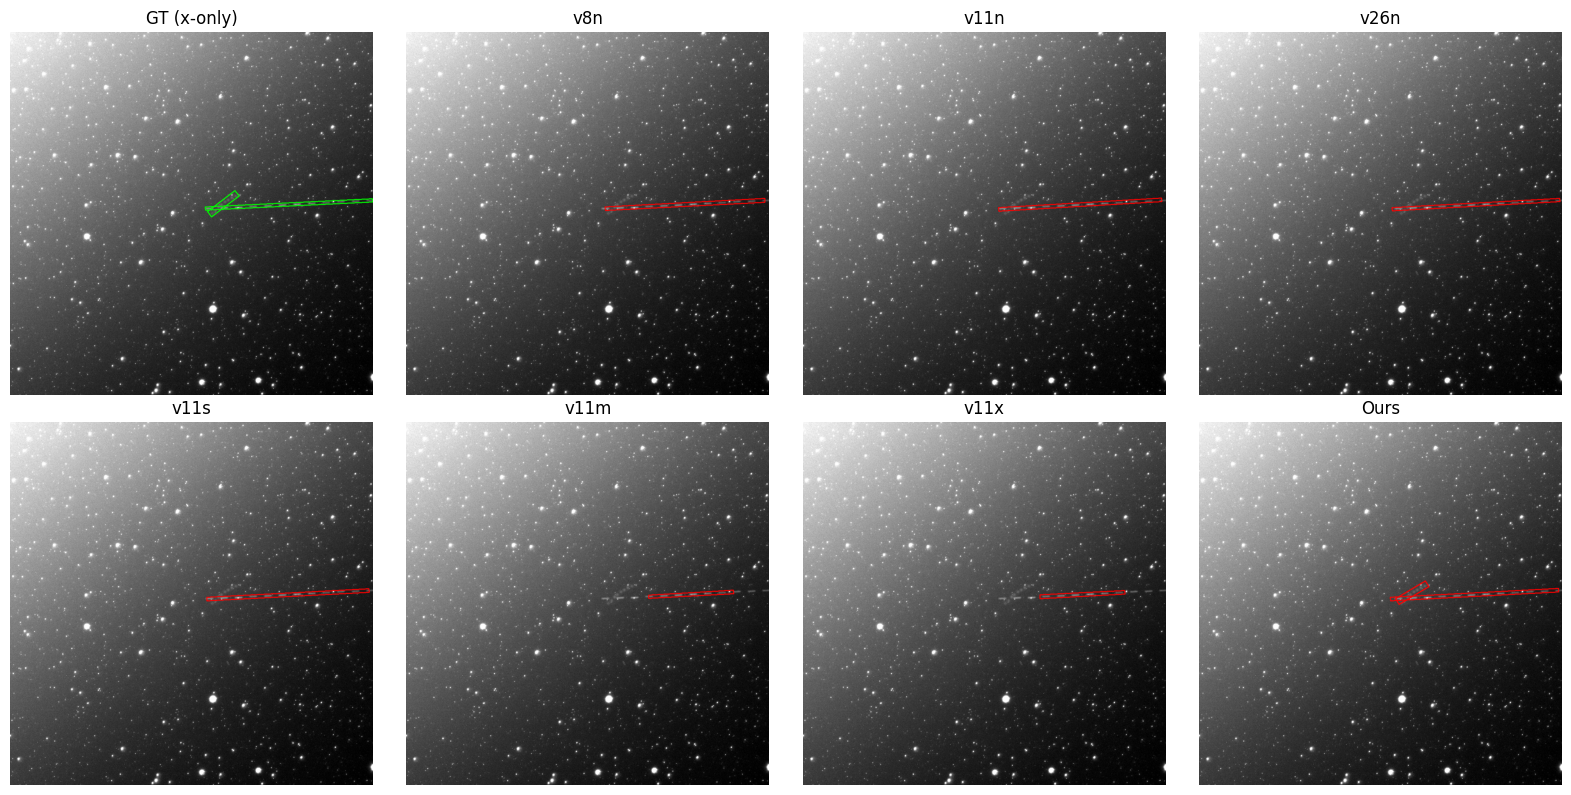

Saved: /home/chris/ultralytics/runs/obb/qualitative/qual_493.png


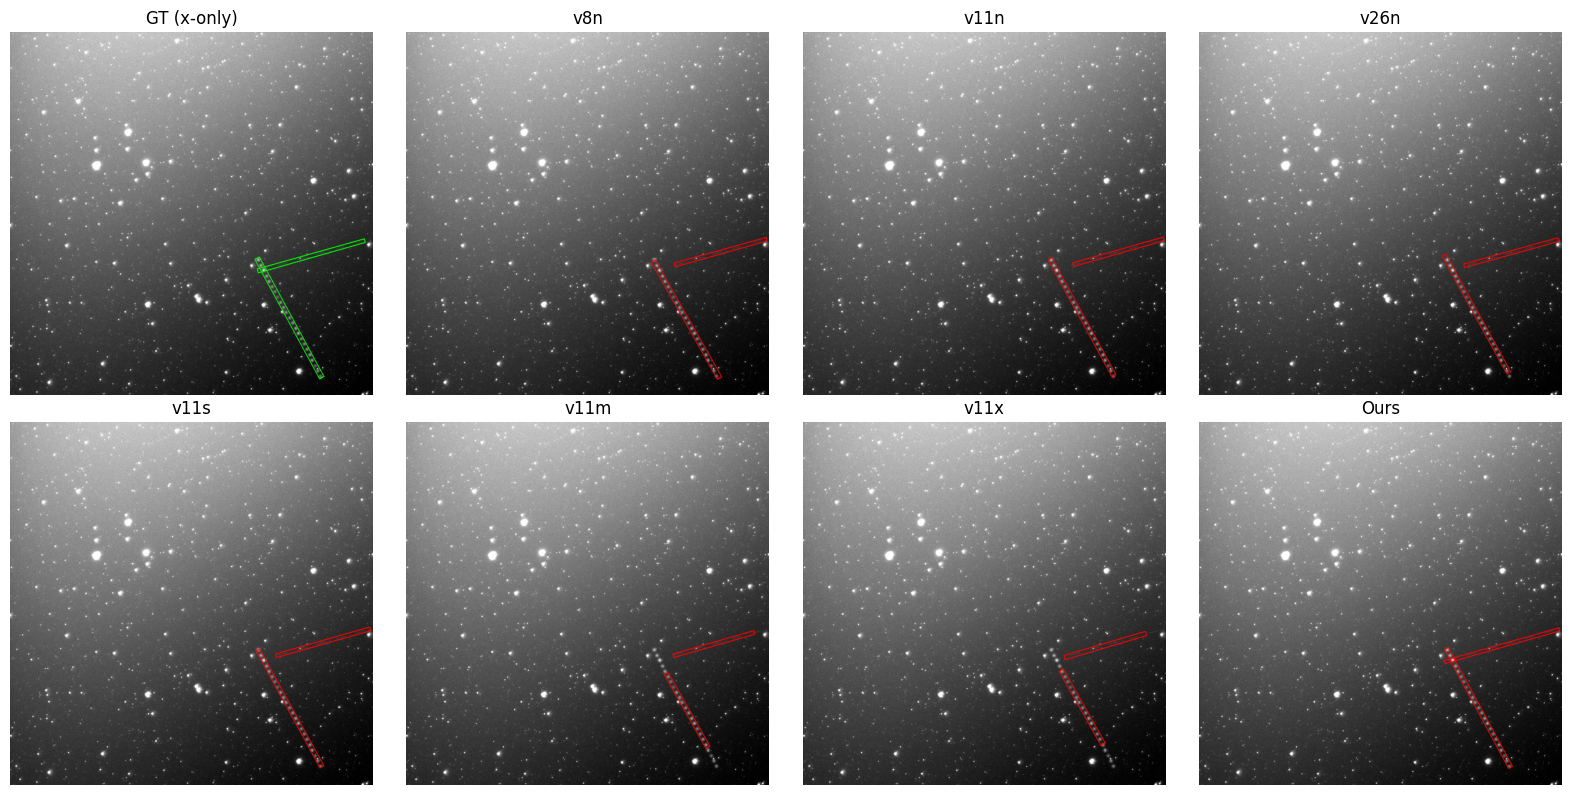

Saved: /home/chris/ultralytics/runs/obb/qualitative/qual_189.png


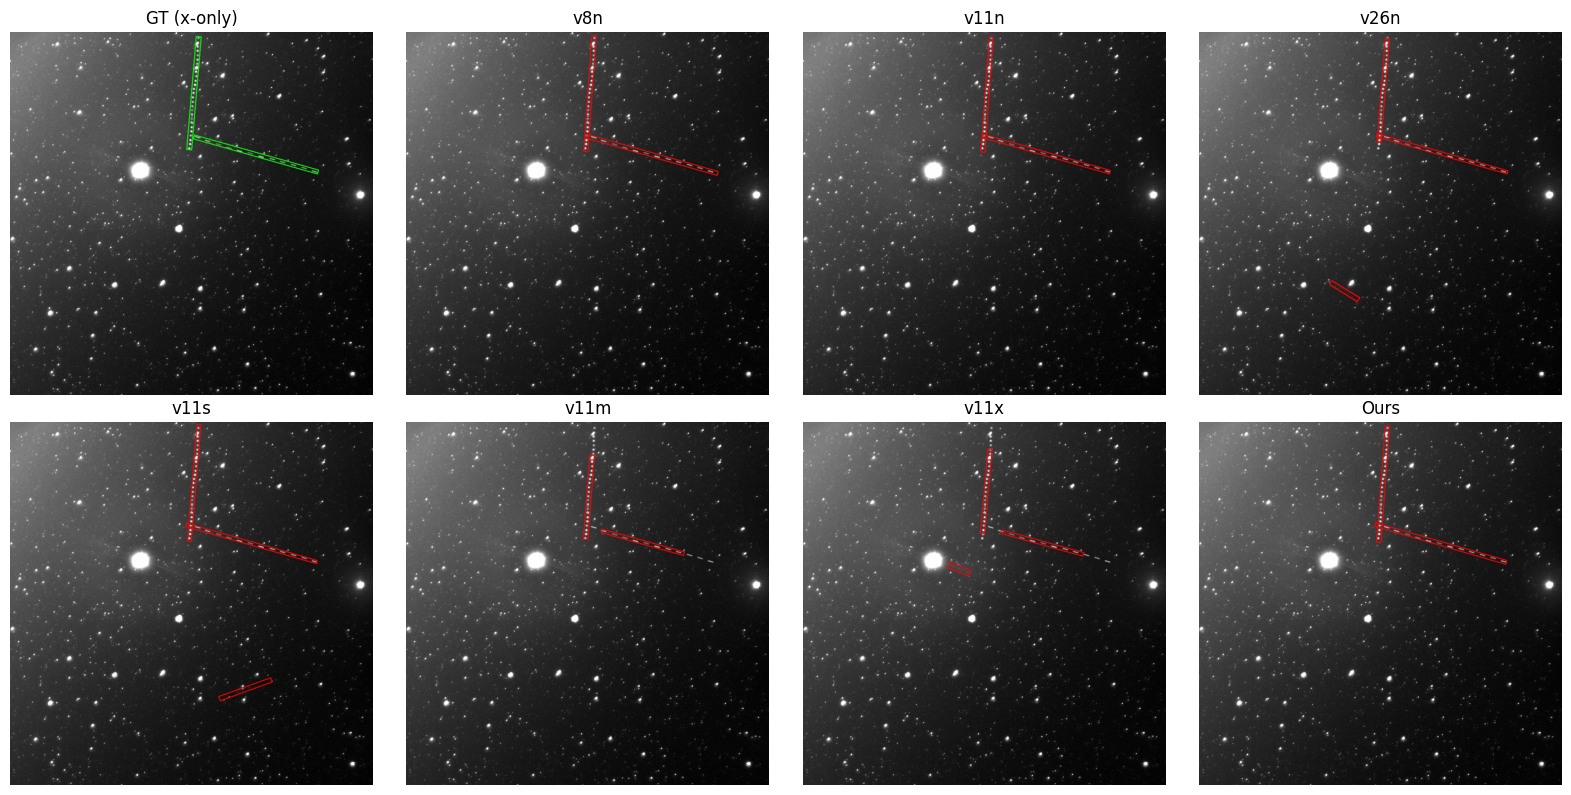

Saved: /home/chris/ultralytics/runs/obb/qualitative/qual_598.png


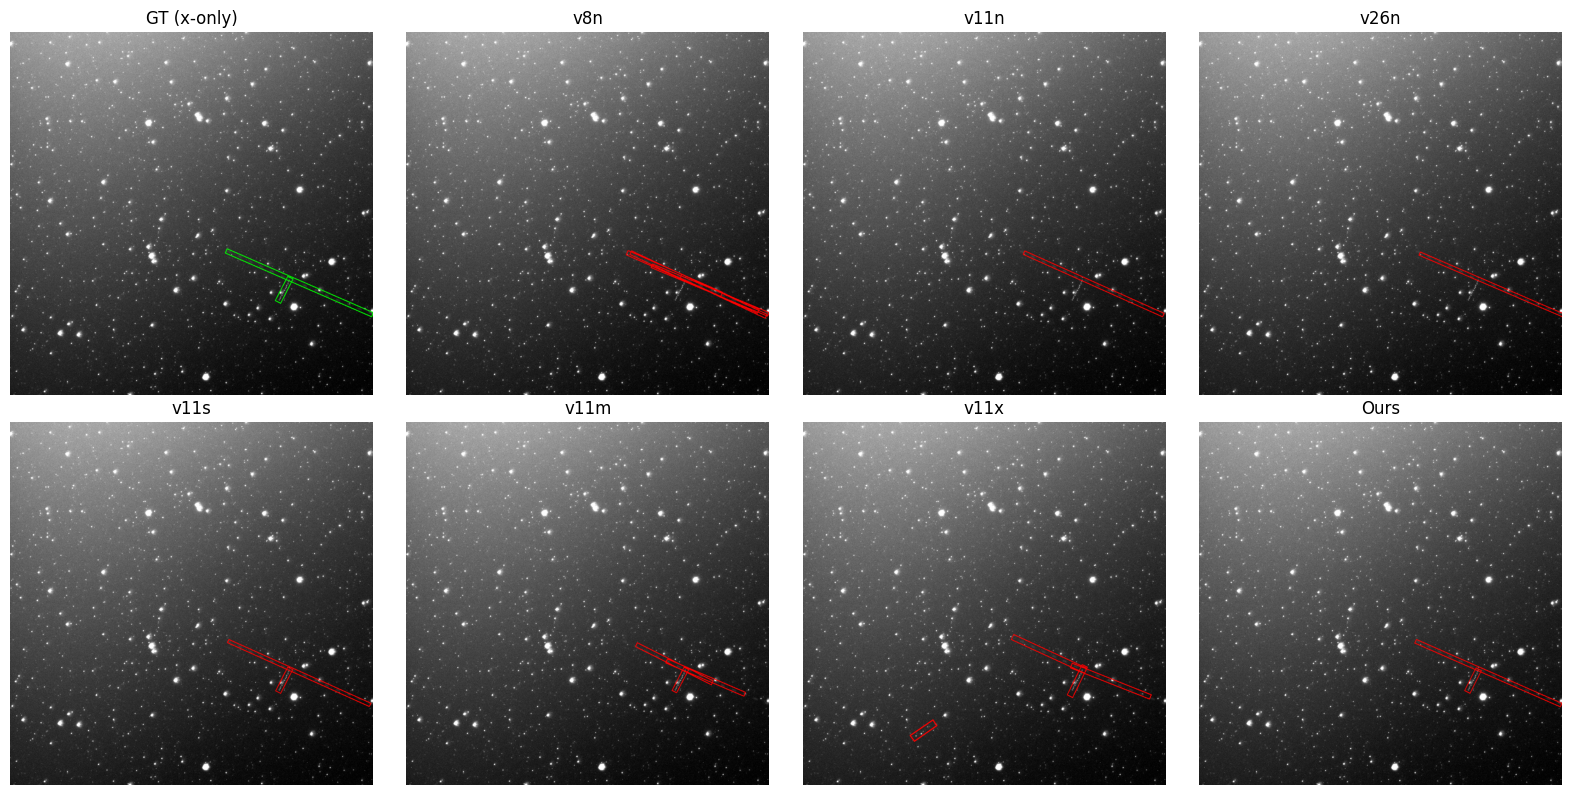

In [40]:
# Load models once
models_x = {k: YOLO(str(v)) for k, v in WEIGHTS_X.items()}
model_ours = YOLO(str(WEIGHTS_OURS))

baseline_order = ['v8n', 'v11n', 'v26n', 'v11s', 'v11m', 'v11x']

def render_grid(sample_name: str, save_dir: Path = None):
    # Load images
    img_x = load_image_gray(IMG_X_VAL / sample_name)
    img_xtsc = load_image_gray(IMG_XTSC_VAL / sample_name)
    img_disp = load_display_image(sample_name)

    h, w = img_disp.shape[:2]

    # GT on display image (projection-only)
    gt_polys = read_obb_label(LBL_X_VAL / (Path(sample_name).stem + '.txt'), w, h)
    gt_img = draw_polys(img_disp, gt_polys, color=(0, 255, 0), thickness=2)

    # Predictions for baselines (x-only) drawn on display image
    pred_imgs = []
    for tag in baseline_order:
        polys = predict_polys(models_x[tag], IMG_X_VAL / sample_name)
        pred_img = draw_polys(img_disp, polys, color=(0, 0, 255), thickness=2)
        pred_imgs.append((tag, pred_img))

    # Our method (XT+SC) drawn on display image
    polys_ours = predict_polys(model_ours, IMG_XTSC_VAL / sample_name)
    ours_img = draw_polys(img_disp, polys_ours, color=(0, 0, 255), thickness=2)

    # Plot 2x4 grid
    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    axes[0].imshow(gt_img[..., ::-1])
    axes[0].set_title('GT (x-only)')
    axes[0].axis('off')

    # Baselines fill axes[1..6]
    for i, (tag, img) in enumerate(pred_imgs, start=1):
        axes[i].imshow(img[..., ::-1])
        axes[i].set_title(tag)
        axes[i].axis('off')

    # Our method at axes[7]
    axes[7].imshow(ours_img[..., ::-1])
    axes[7].set_title('Ours')
    axes[7].axis('off')

    plt.tight_layout()

    if save_dir is not None:
        save_dir.mkdir(parents=True, exist_ok=True)
        out = save_dir / f'qual_{Path(sample_name).stem}.png'
        fig.savefig(out, dpi=200)
        print('Saved:', out)
    plt.show()

# Run for selected samples
OUT_DIR = ROOT / 'runs/obb/qualitative'
for s in SAMPLE_IDS:
    render_grid(s, save_dir=OUT_DIR)
